# 04 — Normalization and activation functions

## Normalization overview

Deep networks train badly when activations drift to very large or tiny scales.
Normalization layers rescale activations to zero mean / unit variance and then apply a
learnable scale `γ` and shift `β`.

* **BatchNorm** — statistics over the *batch* dimension (per feature). Great for CNNs,
  awkward for variable-length sequences and small batches.
* **LayerNorm** — statistics over the *feature* dimension of each token independently.
  Used in every transformer (GPT uses it before attention/FFN and at the end).
* **RMSNorm** — LayerNorm without mean-centering (Llama, Mistral).

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
x = torch.randn(4, 6) * 5 + 3          # 4 tokens, 6 features, badly scaled

ln = nn.LayerNorm(6)
y = ln(x)
print('before  mean/std per token:', x.mean(-1).round(decimals=2), x.std(-1, unbiased=False).round(decimals=2))
print('after   mean/std per token:', y.mean(-1).round(decimals=2), y.std(-1, unbiased=False).round(decimals=2))

# the same thing by hand
manual = (x - x.mean(-1, keepdim=True)) / torch.sqrt(x.var(-1, keepdim=True, unbiased=False) + ln.eps)
print(torch.allclose(manual * ln.weight + ln.bias, y, atol=1e-6))

bn = nn.BatchNorm1d(6)
z = bn(x)
print('batchnorm mean per feature:', z.mean(0).round(decimals=2))

before  mean/std per token: tensor([1.8200, 2.6600, 5.4800, 2.2600]) tensor([3.9300, 5.3800, 2.7400, 6.6200])
after   mean/std per token: tensor([0., -0., -0., -0.], grad_fn=<RoundBackward1>) tensor([1., 1., 1., 1.], grad_fn=<RoundBackward1>)
True
batchnorm mean per feature: tensor([-0., 0., 0., -0., -0., 0.], grad_fn=<RoundBackward1>)


## ReLU, Sigmoid, Tanh activations

Without a non-linearity, stacked linear layers collapse into one linear map. Activations
let networks model non-linear functions.

* **ReLU** `max(0, x)` — cheap, no saturation for x>0; used in our FeedForward.
* **Sigmoid** `1 / (1 + e^{-x})` → (0, 1); saturates → vanishing gradients; used for gates/probabilities.
* **Tanh** → (−1, 1); zero-centred sigmoid; used in RNNs.
* **GELU** — smooth ReLU used by GPT-2/BERT.

relu    tensor([0.0000, 0.0000, 0.0000, 0.5000, 2.0000])
sigmoid tensor([0.1192, 0.3775, 0.5000, 0.6225, 0.8808])
tanh    tensor([-0.9640, -0.4621,  0.0000,  0.4621,  0.9640])
gelu    tensor([-0.0455, -0.1543,  0.0000,  0.3457,  1.9545])


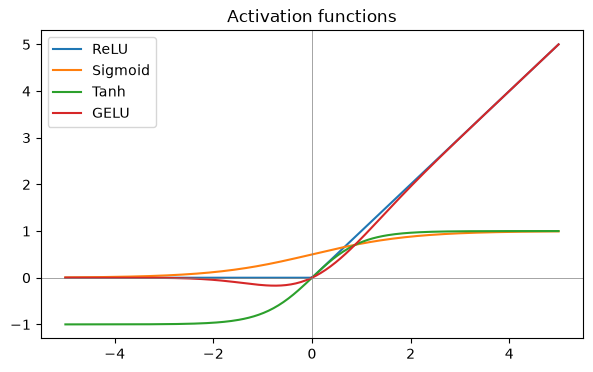

In [2]:
x = torch.tensor([-2.0, -0.5, 0.0, 0.5, 2.0])
print('relu   ', F.relu(x))
print('sigmoid', torch.sigmoid(x))
print('tanh   ', torch.tanh(x))
print('gelu   ', F.gelu(x))

xs = torch.linspace(-5, 5, 200)
plt.figure(figsize=(7, 4))
for name, fn in [('ReLU', F.relu), ('Sigmoid', torch.sigmoid), ('Tanh', torch.tanh), ('GELU', F.gelu)]:
    plt.plot(xs, fn(xs), label=name)
plt.axhline(0, color='grey', lw=0.5); plt.axvline(0, color='grey', lw=0.5)
plt.legend(); plt.title('Activation functions'); plt.show()

In [3]:
# Vanishing gradients: sigmoid's derivative is at most 0.25 and ~0 for large |x|
x = torch.linspace(-6, 6, 7, requires_grad=True)
torch.sigmoid(x).sum().backward()
print('sigmoid grad:', x.grad.round(decimals=4))
x.grad = None
F.relu(x).sum().backward()
print('relu grad:   ', x.grad)

sigmoid grad: tensor([0.0025, 0.0177, 0.1050, 0.2500, 0.1050, 0.0177, 0.0025])
relu grad:    tensor([0., 0., 0., 0., 1., 1., 1.])
